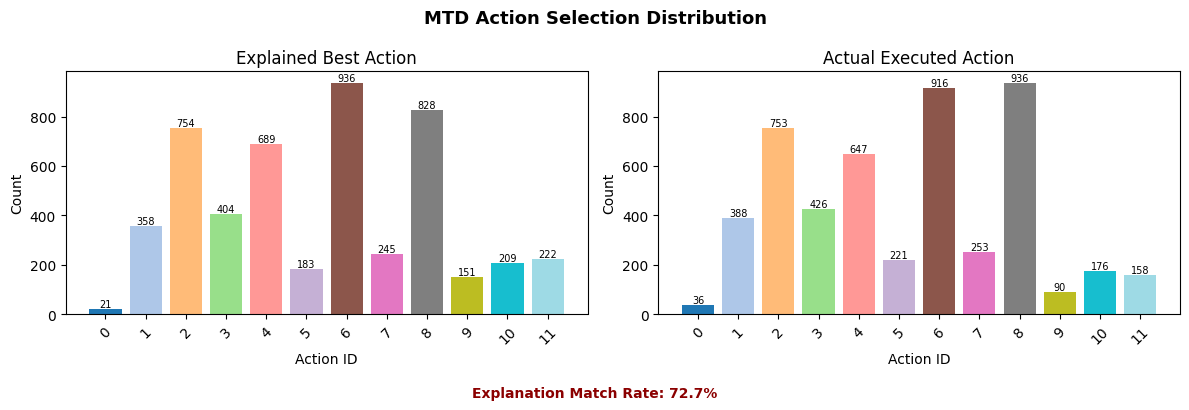

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("envelope_explain.csv")
weights = np.array([0.4, 0.3, 0.3])
COLORS = {"Resource": "steelblue", "Network": "darkorange", "Security": "green"}
window = max(1, len(df) // 50)

# Highlight step: highest absolute value of weighted_security_diff 
highlight_idx   = df["weighted_security_diff"].abs().idxmax()
highlight_step  = df.loc[highlight_idx]

# Color map
action_counts   = df["best_action"].value_counts().sort_index()
unique_actions  = action_counts.index.tolist()
tab20_colors    = plt.cm.tab20(np.linspace(0, 1, len(unique_actions)))
action_color_map = {a: tab20_colors[i] for i, a in enumerate(unique_actions)}

# ============================================================
# Action Selection Distribution（best_action vs env_action）
# ============================================================
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4))
fig1.suptitle("MTD Action Selection Distribution", fontsize=13, fontweight='bold')

for ax, col, title in zip(axes1,
                           ["best_action", "env_action"],
                           ["Explained Best Action", "Actual Executed Action"]):
    counts  = df[col].value_counts().sort_index()
    colors  = [action_color_map.get(a, "gray") for a in counts.index]
    bars    = ax.bar(counts.index.astype(str), counts.values, color=colors)
    ax.set_title(title)
    ax.set_xlabel("Action ID")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                str(val), ha='center', va='bottom', fontsize=7)

# match rate 
match_rate = df["match"].mean() * 100
fig1.text(0.5, 0.01, f"Explanation Match Rate: {match_rate:.1f}%",
          ha='center', fontsize=10, color='darkred', fontweight='bold')
fig1.tight_layout(rect=[0, 0.05, 1, 1])
fig1.savefig("plot1_action_distribution.pdf", dpi=150, bbox_inches="tight")


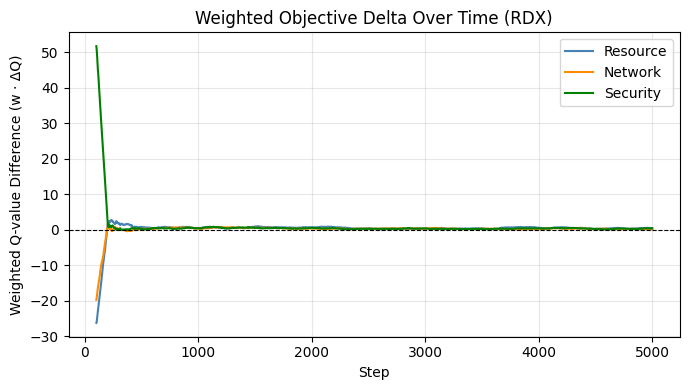

In [113]:
# ============================================================
# Weighted Objective Delta Over Time (RDX)
# ============================================================
fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(df["step"], df["weighted_resource_diff"].rolling(window).mean(),
         label="Resource", color=COLORS["Resource"], linewidth=1.5)
ax2.plot(df["step"], df["weighted_network_diff"].rolling(window).mean(),
         label="Network",  color=COLORS["Network"],  linewidth=1.5)
ax2.plot(df["step"], df["weighted_security_diff"].rolling(window).mean(),
         label="Security", color=COLORS["Security"], linewidth=1.5)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_title("Weighted Objective Delta Over Time (RDX)")
ax2.set_xlabel("Step")
ax2.set_ylabel("Weighted Q-value Difference (w · ΔQ)")
ax2.legend()
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
fig2.savefig("plot2_delta_over_time.pdf", dpi=150, bbox_inches="tight")


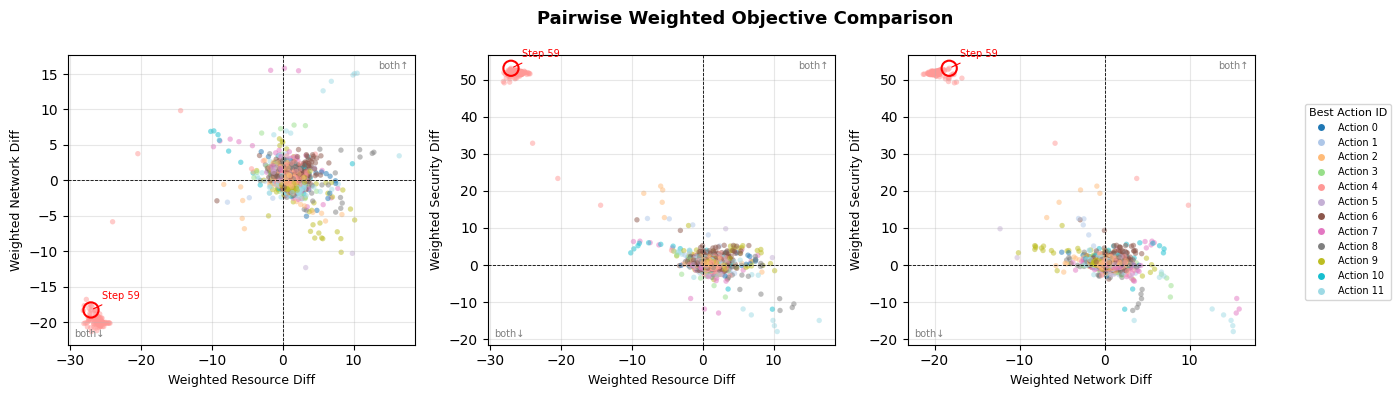

In [114]:
# ============================================================
# Pairwise Weighted Objective Comparison
# ============================================================
fig3, axes3 = plt.subplots(1, 3, figsize=(15, 4))
fig3.suptitle("Pairwise Weighted Objective Comparison", fontsize=13, fontweight='bold')
fig3.subplots_adjust(right=0.85)

pairs = [
    ("weighted_resource_diff", "weighted_network_diff",
     "Weighted Resource Diff", "Weighted Network Diff"),
    ("weighted_resource_diff", "weighted_security_diff",
     "Weighted Resource Diff", "Weighted Security Diff"),
    ("weighted_network_diff",  "weighted_security_diff",
     "Weighted Network Diff",  "Weighted Security Diff"),
]
point_colors = df["best_action"].map(action_color_map).tolist()

for ax, (xcol, ycol, xlabel, ylabel) in zip(axes3, pairs):
    sc = ax.scatter(df[xcol], df[ycol], c=point_colors,
                    alpha=0.5, s=15, edgecolors="none")
    ax.scatter(highlight_step[xcol], highlight_step[ycol],
               facecolors="none", edgecolors="red",
               s=120, zorder=5, linewidths=1.5)
    ax.annotate(f"Step {int(highlight_step['step'])}",
                xy=(highlight_step[xcol], highlight_step[ycol]),
                xytext=(8, 8), textcoords="offset points",
                fontsize=7, color="red",
                arrowprops=dict(arrowstyle="-", color="red", lw=0.8))
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax.axvline(0, color="black", linewidth=0.6, linestyle="--")
    ax.text(0.98, 0.98, "both↑", transform=ax.transAxes,
            ha='right', va='top', fontsize=7, color='gray')
    ax.text(0.02, 0.02, "both↓", transform=ax.transAxes,
            ha='left', va='bottom', fontsize=7, color='gray')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.3)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=action_color_map[a],
               markersize=6, label=f"Action {a}")
    for a in unique_actions
]
fig3.legend(handles=legend_handles, title="Best Action ID",
            bbox_to_anchor=(0.87, 0.5), loc="center left",
            fontsize=7, title_fontsize=8, framealpha=0.8)
fig3.tight_layout(rect=[0, 0, 0.85, 1])
fig3.savefig("plot3_pairwise_scatter.pdf", dpi=150, bbox_inches="tight")


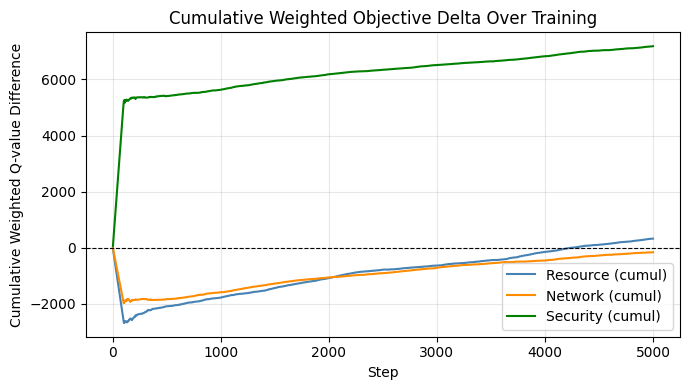

In [115]:
# ============================================================
# Cumulative Weighted Objective Delta Over Training
# ============================================================
fig4, ax4 = plt.subplots(figsize=(7, 4))
ax4.plot(df["step"], df["weighted_resource_diff"].cumsum(),
         label="Resource (cumul)", color=COLORS["Resource"], linewidth=1.5)
ax4.plot(df["step"], df["weighted_network_diff"].cumsum(),
         label="Network (cumul)",  color=COLORS["Network"],  linewidth=1.5)
ax4.plot(df["step"], df["weighted_security_diff"].cumsum(),
         label="Security (cumul)", color=COLORS["Security"], linewidth=1.5)
ax4.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax4.set_title("Cumulative Weighted Objective Delta Over Training")
ax4.set_xlabel("Step")
ax4.set_ylabel("Cumulative Weighted Q-value Difference")
ax4.legend()
ax4.grid(True, alpha=0.3)
fig4.tight_layout()
fig4.savefig("plot4_cumulative_delta.pdf", dpi=150, bbox_inches="tight")


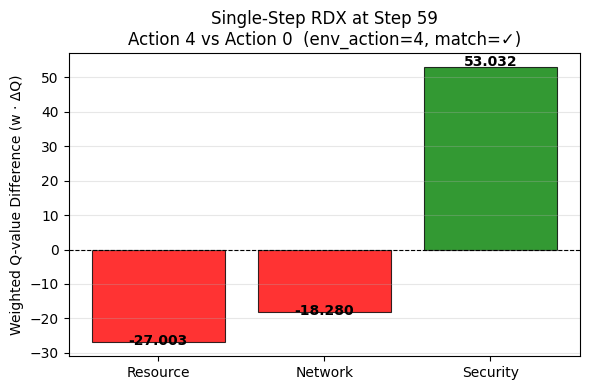

In [116]:
# ============================================================
# Single-Step RDX
# ============================================================
fig5, ax5 = plt.subplots(figsize=(6, 4))
labels5 = ["Resource", "Network", "Security"]
deltas5 = [highlight_step["weighted_resource_diff"],
           highlight_step["weighted_network_diff"],
           highlight_step["weighted_security_diff"]]
colors5 = ["green" if d > 0 else "red" for d in deltas5]
bars5   = ax5.bar(labels5, deltas5, color=colors5, alpha=0.8,
                  edgecolor="black", linewidth=0.8)
ax5.axhline(0, color="black", linewidth=0.8, linestyle="--")
for bar, val in zip(bars5, deltas5):
    ax5.text(bar.get_x() + bar.get_width()/2,
             val + (0.3 if val >= 0 else -0.8),
             f"{val:.3f}", ha='center', fontsize=10, fontweight='bold')
ax5.set_title(
    f"Single-Step RDX at Step {int(highlight_step['step'])}\n"
    f"Action {int(highlight_step['best_action'])} vs "
    f"Action {int(highlight_step['alt_action'])}  "
    f"(env_action={int(highlight_step['env_action'])}, "
    f"match={'✓' if highlight_step['match'] else '✗'})"
)
ax5.set_ylabel("Weighted Q-value Difference (w · ΔQ)")
ax5.grid(True, alpha=0.3, axis='y')
fig5.tight_layout()
fig5.savefig("plot5_single_step_rdx.pdf", dpi=150, bbox_inches="tight")


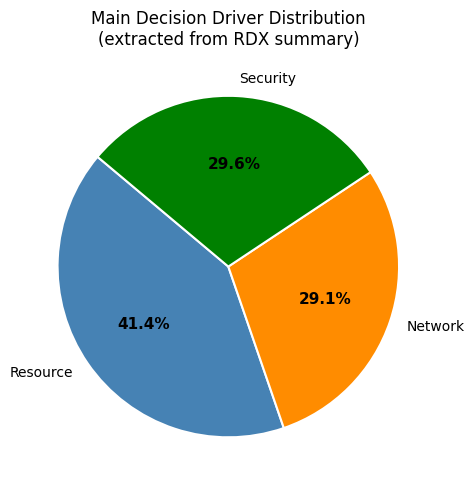

In [117]:
# ============================================================
# Main Decision Driver Distribution (pie chart)
# ============================================================
fig6, ax6 = plt.subplots(figsize=(6, 5))

def extract_main_reason(summary_str):
    try:
        return summary_str.split("mainly due to better ")[1].split(",")[0].strip()
    except:
        return "Unknown"

df["main_reason"] = df["summary"].apply(extract_main_reason)
reason_counts_s   = df["main_reason"].value_counts()
reason_names      = ["Resource", "Network", "Security"]
reason_counts     = [reason_counts_s.get(n, 0) for n in reason_names]
pie_colors        = [COLORS[n] for n in reason_names]

wedges, texts, autotexts = ax6.pie(
    reason_counts, labels=reason_names, colors=pie_colors,
    autopct="%1.1f%%", startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
ax6.set_title("Main Decision Driver Distribution\n(extracted from RDX summary)")
fig6.tight_layout()
fig6.savefig("plot6_main_reason_pie.pdf", dpi=150, bbox_inches="tight")
